In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [4]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

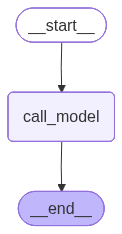

In [6]:
graph = builder.compile()
graph

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Tanish."}]})


{'messages': [HumanMessage(content='Hi! My name is Tanish.', additional_kwargs={}, response_metadata={}, id='f13456d9-8105-46f9-8bfb-ee8dca5f17d9'),
  AIMessage(content="Hi Tanish! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dbf05-068c-7e31-a002-4379cc638c2d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 19, 'total_tokens': 28, 'input_token_details': {'cache_read': 0}})]}

In [9]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='a0dfc2ab-ea53-4166-ba28-8564bf8b74e2'),
  AIMessage(content='I do not have access to your personal information, including your name. I am a large language model, trained by Google.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dbf05-317d-7c31-9651-abca609dc3aa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 25, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}})]}

WITH MEMORY

In [ ]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}